In [2]:
import numpy as np
import addcopyfighandler
import matplotlib.pyplot as plt
import mne 

In [3]:
%matplotlib qt

Channels marked as bad:
['MEG 2443', 'EEG 053']


In [5]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file C:\Users\user\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In [6]:
print(raw)
print(raw.info)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>
<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


In [7]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).
Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x182092bef00) at 0x000001820F56FD80>

In [ ]:
# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components = 20, random_state = 97, max_iter = 800)
ica.fit(raw)
ica.exclude = [1, 2] #details on how we picked these are omitted here
ica.plot_properties(raw, picks=ica.exclude)

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.4s.
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 1400x1200 with 6 Axes>, <Figure size 1400x1200 with 6 Axes>]

In [ ]:
orig_raw = raw.copy()
raw.load_data()
ica.apply(raw)

#show some frontal channels to clearly illustrate the artifact removal
chs = [
    "MEG 0111",
    "MEG 0121",
    "MEG 0131",
    "MEG 0211",
    "MEG 0221",
    "MEG 0231",
    "MEG 0311",
    "MEG 0321",
    "MEG 0331",
    "MEG 1511",
    "MEG 1521",
    "MEG 1531",
    "EEG 001",
    "EEG 002",
    "EEG 003",
    "EEG 004",
    "EEG 005",
    "EEG 006",
    "EEG 007",
    "EEG 008",
]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
orig_raw.plot(order = chan_idxs, start = 12, duration = 4)
raw.plot(order = chan_idxs, start = 12, duration = 4)

Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 364 PCA components


<mne_qt_browser._pg_figure.MNEQtBrowser(0x23b9db0dbf0) at 0x0000023B8B682FC0>

In [ ]:
events = mne.find_events(raw, stim_channel="STI 014")
print(events[:5]) #show the first 5 events

Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]]


In [ ]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "smiley": 5,
    "buttonpress": 32,
}

fig = mne.viz.plot_events(
    events, event_id=event_dict, sfreq=raw.info["sfreq"], first_samp=raw.first_samp
)

In [ ]:
reject_criteria = dict(
    mag = 4000e-15, #4000 fT
    grad = 4000e-13, #4000fT/cm
    eeg = 150e-6, #150 uV
    eog = 250e-6, # 250 uV
)
epochs = mne.Epochs(
    raw,
    events,
    event_id = event_dict,
    tmin = -0.2,
    tmax = 0.5,
    reject = reject_criteria,
    preload = True,
)

Not setting metadata
319 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Using data from preloaded Raw for 319 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EEG : ['EEG 008']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
10 bad epochs dropped


In [ ]:
conds_we_care_about = ["auditory/left", "auditory/right", "visual/left", "visual/right"]
epochs.equalize_event_counts(conds_we_care_about) # this operates in-place
aud_epochs = epochs["auditory"]
vis_epochs = epochs["visual"]
del raw, epochs # free up memory

Dropped 7 epochs: 121, 195, 258, 271, 273, 274, 275


In [ ]:
aud_epochs.plot_image(picks=["MEG 1332", "EEG 021"])

Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 1280x960 with 4 Axes>, <Figure size 1280x960 with 4 Axes>]

In [ ]:
frequencies = np.arange(7, 30, 3)
power = aud_epochs.compute_tfr(
    "morlet", n_cycles=2, return_itc=False, freqs = frequencies, decim=3, average=True
)
power.plot(["MEG 1332"])

No baseline correction applied


[<Figure size 1280x960 with 2 Axes>]

In [ ]:
aud_evoked = aud_epochs.average()
vis_evoked = vis_epochs.average()

mne. viz.plot_compare_evokeds(
    dict(auditory=aud_evoked, visual=vis_evoked),
    legend="upper left",
    show_sensors="upper right",
)

Multiple channel types selected, returning one figure per type.
combining channels using RMS (grad channels)
combining channels using RMS (grad channels)
combining channels using RMS (mag channels)
combining channels using RMS (mag channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


[<Figure size 1600x1200 with 2 Axes>,
 <Figure size 1600x1200 with 2 Axes>,
 <Figure size 1600x1200 with 2 Axes>]

Projections have already been applied. Setting proj attribute to True.


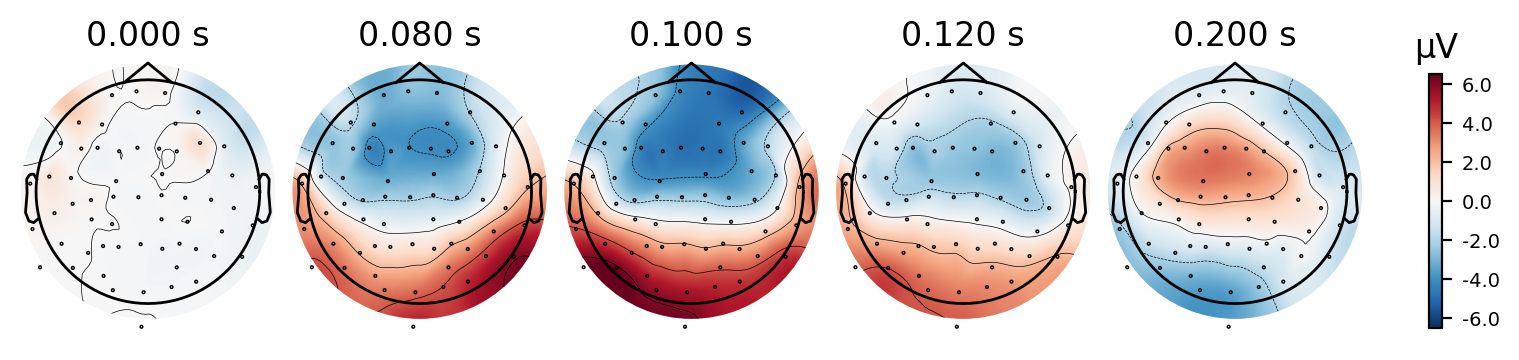

In [ ]:
aud_evoked.plot_joint(picks="eeg")
aud_evoked.plot_topomap(times=[0.0, 0.08, 0.1, 0.12, 0.2], ch_type = "eeg")

In [ ]:
evoked_diff = mne.combine_evoked([aud_evoked, vis_evoked], weights=[1,-1])
evoked_diff.pick(picks="mag").plot_topo(color="r", legend=False)

In [ ]:
#load inverse operator
inverse_operator_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis-meg-oct-6-meg-inv.fif"
)
inv_operator = mne.minimum_norm.read_inverse_operator(inverse_operator_file)
# set signal-to-noise ratio (SNR) to compute regularization parameter (lambda2)
snr = 3.0
lambda2 = 1.0 / snr ** 2
#generate the source time course (STC)
stc = mne.minimum_norm.apply_inverse(
    vis_evoked, inv_operator , lambda2=lambda2, method="MNE"
) # or dSPM. sLORETA, eLORETA

In [ ]:
#path to sujects' MRI files
subjects_dir = sample_data_folder / "subjects"
#plot the STC
stc.plot(
    initial_time=0.1, hemi="split", views=["lat", "med"], subjects_dir=subjects_dir
)